# Aania — Cluster 5 Model

This cluster has 916 companies, out of which 72 are bankrupt (~8%).  

## 1. Setup

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Accuracy = (TT / (TT + TF)) 

Since the dataset is imbalanced, normal accuracy can look high even if the model is not identifying bankrupt companies properly. So I created a custom function to calculate the required metric.

In [23]:
def eq1_accuracy(y_true, y_pred):
    TT = ((y_true == 1) & (y_pred == 1)).sum()
    TF = ((y_true == 1) & (y_pred == 0)).sum()
    return TT / (TT + TF) if (TT + TF) > 0 else 0.0

def show_confusion(y_true, y_pred, name):
    FF = ((y_true == 0) & (y_pred == 0)).sum()
    FT = ((y_true == 0) & (y_pred == 1)).sum()
    TT = ((y_true == 1) & (y_pred == 1)).sum()
    TF = ((y_true == 1) & (y_pred == 0)).sum()
    print(f'{name}:')
    print(f'  FF: {FF:>4}    FT: {FT:>4}')
    print(f'  TT: {TT:>4}    TF: {TF:>4}')
    print(f'  Eq.1 acc: {eq1_accuracy(y_true, y_pred):.4f}')
    return TT, TF

## 2. Load the cluster data

In [24]:
df = pd.read_csv("../../Clusters/cluster_5.csv")
print(f'Shape: {df.shape}')
print(f'Bankrupts: {df["Bankrupt?"].sum()} / {len(df)} ({df["Bankrupt?"].mean()*100:.2f}%)')

Shape: (916, 98)
Bankrupts: 72 / 916 (7.86%)


This cluster is moderately imbalanced, but still has enough bankrupt examples to train a model without needing heavy resampling techniques.

Drop columns that can't be features:
- `Index` is a row identifier
- `Cluster` is the cluster label (would leak the answer)
- Columns with only one unique value don’t help the model learn anything, so I removed them.

In [25]:
y = df['Bankrupt?'].values
X = df.drop(columns=['Bankrupt?', 'Index', 'Cluster'])

const_cols = [c for c in X.columns if X[c].nunique() <= 1]
print(f'Constant columns dropped: {const_cols}')
X = X.drop(columns=const_cols)
print(f'Features: {X.shape}')

Constant columns dropped: ['Liability-Assets Flag', 'Net Income Flag']
Features: (916, 93)


## Data Analysis

In [26]:
# Missing values check
missing = X.isnull().sum()
n_missing = (missing > 0).sum()
print(f'Columns with missing values: {n_missing}')
if n_missing > 0:
    print(missing[missing > 0])
else:
    print('No missing values - data is clean')

Columns with missing values: 0
No missing values - data is clean


In [27]:
# Duplicate rows check
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [28]:
# Constant columns - no predictive value, will be dropped before modeling
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print(f'Constant columns ({len(const_cols)}):')
for c in const_cols:
    print(f'  - {c.strip()}')

Constant columns (3):
  - Liability-Assets Flag
  - Net Income Flag
  - Cluster


## 3. Feature selection with L1 logistic regression

The idea is that L1 pushes less important feature coefficients to zero, which helps automatically select a smaller set of useful features.

Since the project also penalizes using too many features, I tried different values of C to see how many features are selected and how the performance changes.

In [29]:
X_scaled = StandardScaler().fit_transform(X)
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

print(f'{"C":>8} {"# features":>11} {"CV F1":>8}')
print('-' * 30)
for C in [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]:
    lr = LogisticRegression(penalty='l1', solver='saga', C=C,
                            class_weight='balanced', max_iter=5000,
                            random_state=RANDOM_STATE)
    lr.fit(X_scaled, y)
    n_feat = (lr.coef_[0] != 0).sum()
    f1 = cross_val_score(lr, X_scaled, y, cv=cv, scoring='f1').mean()
    print(f'{C:>8.3f} {n_feat:>11d} {f1:>8.4f}')

       C  # features    CV F1
------------------------------
   0.010           5   0.3614
   0.050          17   0.4065
   0.100          30   0.3955
   0.200          41   0.3926
   0.500          57   0.3430
   1.000          67   0.3414


F1 doesn't improve much past 5 features (around 0.36 at C=0.01 vs 0.40 at higher C with way more features). Going with C=0.01 — picking the smallest viable set since N_features is also part of the grade.

In [30]:
C_chosen = 0.01
selector = LogisticRegression(penalty='l1', solver='saga', C=C_chosen,
                              class_weight='balanced', max_iter=5000,
                              random_state=RANDOM_STATE)
selector.fit(X_scaled, y)

selected_features = X.columns[selector.coef_[0] != 0].tolist()
N_FEATURES = len(selected_features)
X_selected = X[selected_features]

print(f'Selected {N_FEATURES} features:\n')
for i, f in enumerate(selected_features, 1):
    coef = selector.coef_[0][list(X.columns).index(f)]
    print(f'  {i}. {f.strip():<55} coef={coef:+.3f}')

Selected 5 features:

  1. ROA(C) before interest and depreciation before interest coef=-0.205
  2. Persistent EPS in the Last Four Seasons                 coef=-0.086
  3. Debt ratio %                                            coef=+0.348
  4. Net worth/Assets                                        coef=-0.348
  5. Current Liability to Assets                             coef=+0.022


The selected features make sense from a financial perspective.

For example, companies with higher debt or weaker financial stability are more likely to go bankrupt, while stronger profitability indicators reduce that risk.

So the model seems to be picking meaningful features.

## 4. Three base models

The project requires at least 3 base models for stacking.

I chose the following models:

- Logistic Regression → good for simple relationships
- Random Forest → captures non-linear patterns and interactions
- Gradient Boosting → generally performs well on structured/tabular data

I used different types of models so that stacking can combine their strengths.

I did not use SMOTE or other resampling methods here because this cluster already has enough bankrupt examples, and using synthetic data could lead to overfitting.

In [31]:
base_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=2000,
                               random_state=RANDOM_STATE))
])

base_rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                                  class_weight='balanced',
                                  random_state=RANDOM_STATE)

base_gb = GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                     learning_rate=0.05,
                                     random_state=RANDOM_STATE)

base_models = [('lr', base_lr), ('rf', base_rf), ('gb', base_gb)]

Quick CV sanity check on each base model individually before stacking them.

In [32]:
for name, model in base_models:
    f1 = cross_val_score(model, X_selected, y, cv=cv, scoring='f1').mean()
    print(f'{name}: CV F1 = {f1:.4f}')

lr: CV F1 = 0.3846
rf: CV F1 = 0.3058
gb: CV F1 = 0.1955


## 5. Stacking with cross-validation

In [33]:
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=2000,
                                       random_state=RANDOM_STATE),
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    stack_method='predict_proba',
)

stacking.fit(X_selected, y)
print('stacking model fitted')

stacking model fitted


## 6. Threshold tuning

By default, the threshold is 0.5, but with imbalanced data this can miss many bankrupt companies.

So I tried different threshold values and selected the one that gives the best Eq.1 accuracy.

At the same time, I made sure that the percentage of companies predicted as bankrupt stays below 25%, so that the final submission does not violate the project constraint.

In [34]:
oof_proba = cross_val_predict(stacking, X_selected, y, cv=cv,
                              method='predict_proba')[:, 1]

print(f'{"thresh":>8} {"pred%":>8} {"TT":>4} {"TF":>4} {"Eq.1":>8}')
print('-' * 40)

best_thresh = 0.5
best_acc = 0.0
for t in np.arange(0.20, 0.65, 0.05):
    preds = (oof_proba >= t).astype(int)
    pred_rate = preds.mean()
    TT = ((y == 1) & (preds == 1)).sum()
    TF = ((y == 1) & (preds == 0)).sum()
    acc = eq1_accuracy(y, preds)
    flag = ' *' if (acc > best_acc and pred_rate < 0.25) else ''
    print(f'{t:>8.2f} {pred_rate*100:>7.2f}% {TT:>4} {TF:>4} {acc:>8.4f}{flag}')
    if acc > best_acc and pred_rate < 0.25:
        best_acc = acc
        best_thresh = t

print(f'\nPicked threshold: {best_thresh:.2f}  (CV Eq.1 acc {best_acc:.4f})')

  thresh    pred%   TT   TF     Eq.1
----------------------------------------
    0.20   48.80%   67    5   0.9306
    0.25   41.92%   65    7   0.9028
    0.30   36.57%   65    7   0.9028
    0.35   32.86%   65    7   0.9028
    0.40   29.26%   62   10   0.8611
    0.45   27.73%   60   12   0.8333
    0.50   24.34%   59   13   0.8194 *
    0.55   22.38%   58   14   0.8056
    0.60   19.98%   55   17   0.7639

Picked threshold: 0.50  (CV Eq.1 acc 0.8194)


## 7. Save model bundle

I saved everything together (features + model + threshold) so it can be directly used during the generalization phase without re-running training.

In [35]:
model_bundle = {
    'selected_features': selected_features,
    'stacking_model':    stacking,
    'threshold':         best_thresh,
    'n_features':        N_FEATURES,
}

def predict_with_bundle(bundle, df_input):
    X_sel = df_input[bundle['selected_features']]
    proba = bundle['stacking_model'].predict_proba(X_sel)[:, 1]
    return (proba >= bundle['threshold']).astype(int)

joblib.dump(model_bundle, 'aania_cluster5_model.joblib')
print('saved: aania_cluster5_model.joblib')

loaded = joblib.load('aania_cluster5_model.joblib')
X_full = df.drop(columns=['Bankrupt?', 'Index', 'Cluster'] + const_cols)
status = 'PASSED' if (predict_with_bundle(loaded, X_full) == predict_with_bundle(model_bundle, X_full)).all() else 'FAILED'
print(f'reload check: {status}')

saved: aania_cluster5_model.joblib
reload check: PASSED


## 8. Table 3 numbers

As required in the project, TT and TF are calculated using the original training data for this cluster (not a split).

These values will be used directly in Table 3 for evaluation.

In [36]:
y_pred_train = predict_with_bundle(model_bundle, X_full)

print('=' * 60)
print('TABLE 3 NUMBERS — Cluster 5')
print('=' * 60)
TT, TF = show_confusion(y, y_pred_train, 'Stacking model')
print()
print(f'  Companies:    {len(y)}')
print(f'  Bankrupt:     {y.sum()}')
print(f'  N_features:   {N_FEATURES}')
print(f'  Train Eq.1:   {eq1_accuracy(y, y_pred_train):.4f}')
print('=' * 60)

TABLE 3 NUMBERS — Cluster 5
Stacking model:
  FF:  698    FT:  146
  TT:   66    TF:    6
  Eq.1 acc: 0.9167

  Companies:    916
  Bankrupt:     72
  N_features:   5
  Train Eq.1:   0.9167


## 9. Confusion matrices

In [37]:
fitted_bases = stacking.named_estimators_

for name in ['lr', 'rf', 'gb']:
    show_confusion(y, fitted_bases[name].predict(X_selected), f'Base [{name.upper()}]')
    print()

show_confusion(y, stacking.predict(X_selected), 'Meta (default threshold 0.5)')
print()
show_confusion(y, y_pred_train, f'Meta (tuned threshold {best_thresh:.2f})  <-- SUBMITTING')

Base [LR]:
  FF:  666    FT:  178
  TT:   60    TF:   12
  Eq.1 acc: 0.8333

Base [RF]:
  FF:  816    FT:   28
  TT:   72    TF:    0
  Eq.1 acc: 1.0000

Base [GB]:
  FF:  844    FT:    0
  TT:   50    TF:   22
  Eq.1 acc: 0.6944

Meta (default threshold 0.5):
  FF:  698    FT:  146
  TT:   66    TF:    6
  Eq.1 acc: 0.9167

Meta (tuned threshold 0.50)  <-- SUBMITTING:
  FF:  698    FT:  146
  TT:   66    TF:    6
  Eq.1 acc: 0.9167


(np.int64(66), np.int64(6))

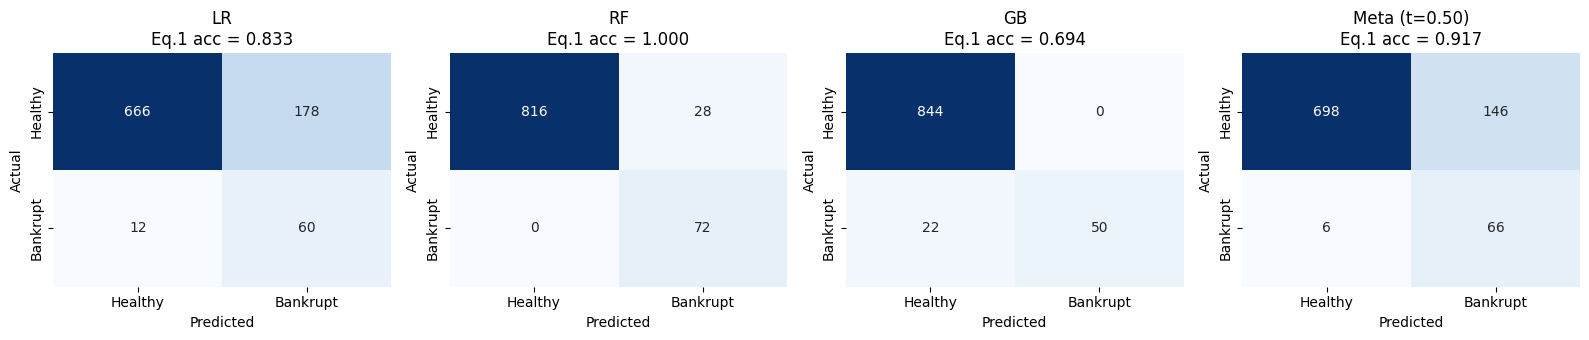

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
plots = [
    ('LR', fitted_bases['lr'].predict(X_selected)),
    ('RF', fitted_bases['rf'].predict(X_selected)),
    ('GB', fitted_bases['gb'].predict(X_selected)),
    (f'Meta (t={best_thresh:.2f})', y_pred_train),
]
for ax, (name, pred) in zip(axes, plots):
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Healthy', 'Bankrupt'], yticklabels=['Healthy', 'Bankrupt'])
    ax.set_title(f'{name}\nEq.1 acc = {eq1_accuracy(y, pred):.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## For the team report

| Subgroup ID | Name | Companies | Bankrupt | TT | TF | N_features |
|---|---|---|---|---|---|---|
| 5 | Aania | 916 | 72 | 66 | 6 | 5 |

My main focus was:
- capturing as many bankrupt companies as possible
- keeping the number of features low
- avoiding overfitting